# 07. 장애인콜택시 의료 목적지 × 의료기관 분포 분석 — 핵심 분석 및 인사이트

이 노트북은 STEP4(데이터 분석)와 STEP5(결과 공유)를 다룬다. STEP1~3은 `05_medical_destination_purpose_and_data.ipynb`,
`06_medical_destination_eda.ipynb`, 작업계획은 `notebooks_docs_lye/plan_medical_destination_analysis.md` 참고.

## 이 노트북의 설계 — 전체콜 vs 의료목적콜 병렬 비교

05에서 만든 결합 데이터는 두 버전이다.

- **전체콜**: `콜택시_목적지_건수` — 이용목적과 무관하게 서울 25개구로 향한 모든 탑승완료 건수
- **의료목적콜**: `콜택시_의료목적지_건수` — 이용목적이 치료/재활/예약치료/예약재활/치료광역인 건수만 (전체의 9.25%)

연구 주제가 "의료 목적지 분석"이므로 의료목적콜이 개념적으로 더 정확하지만, 표본이 9%로 줄어든다. 반대로 전체콜은 표본이 크지만
"의료기관과의 관계"라는 해석이 간접적이다. **이 노트북은 두 버전을 처음부터 끝까지 나란히 제시하며, 한쪽을 정답으로 취급하지 않는다.**

## 분석 단위와 한계
- 주 분석단위: **구·동**(전체콜 431개, 의료목적콜 416개). 구 단위(25개)는 보조로만 참고
- ⚠️ **행정동 인구·면적 편차를 보정하지 않았다.** 콜 건수·의료기관 수 모두 동의 규모(인구·면적)에 영향받을 수 있어,
  아래에서 관찰되는 상관관계는 "의료기관이 많아서"가 아니라 "동네 자체가 커서"일 가능성을 배제하지 못한다.
  이는 이번 분석의 핵심 한계이며, 향후 인구 대비 정규화가 추가 과제로 남는다.
- `data/raw/hospital_info_seoul.csv`는 서울시 전체 의료기관이 아니라 P1(핵심)+P2(보조) 우선순위군만 수집한 것 (근거: 05 노트북 2-5절)

## ⚠️ 해석 원칙
모든 결과는 [확인된 사실]/[탐색적 관계]/[가설]/[인과관계] 4단계로 구분한다. 상관관계가 확인되어도 인과관계로 해석하지 않는다.

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 60)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FACILITY_COLS = ["의원", "한의원", "병원", "종합병원", "요양병원", "상급종합병원", "보건소", "보건지소", "정신병원"]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: C:\Users\young\my_project\260901_call_taxi_DA


## 데이터 로드

In [2]:
dong_all = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined.csv", encoding="utf-8-sig")
gu_all = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined.csv", encoding="utf-8-sig")
dong_med = pd.read_csv(PROCESSED_DIR / "region_dong_call_hospital_combined_medical.csv", encoding="utf-8-sig")
gu_med = pd.read_csv(PROCESSED_DIR / "region_gu_call_hospital_combined_medical.csv", encoding="utf-8-sig")

# 상관/산점도에서 공통으로 쓸 수 있도록 콜 건수 컬럼명을 통일한다
dong_all = dong_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
gu_all = gu_all.rename(columns={"콜택시_목적지_건수": "콜건수"})
dong_med = dong_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})
gu_med = gu_med.rename(columns={"콜택시_의료목적지_건수": "콜건수"})

DATASETS = {
    "전체콜 (구·동)": dong_all,
    "의료목적콜 (구·동)": dong_med,
}

for name, df in DATASETS.items():
    print(f"{name}: {df.shape}, 콜건수 합계 {df['콜건수'].sum():,}, 의료기관_총수 합계 {df['의료기관_총수'].sum():,}")

전체콜 (구·동): (431, 15), 콜건수 합계 1,369,283, 의료기관_총수 합계 14,823
의료목적콜 (구·동): (416, 15), 콜건수 합계 126,705, 의료기관_총수 합계 14,749


## 1. 목적지 건수 vs 의료기관 수 (4-1)

구·동 단위로 X=의료기관 총수, Y=콜 건수 산점도를 전체콜/의료목적콜 나란히 그린다.
이상치는 빨간점으로 표시하고 행정동 기입하였음.

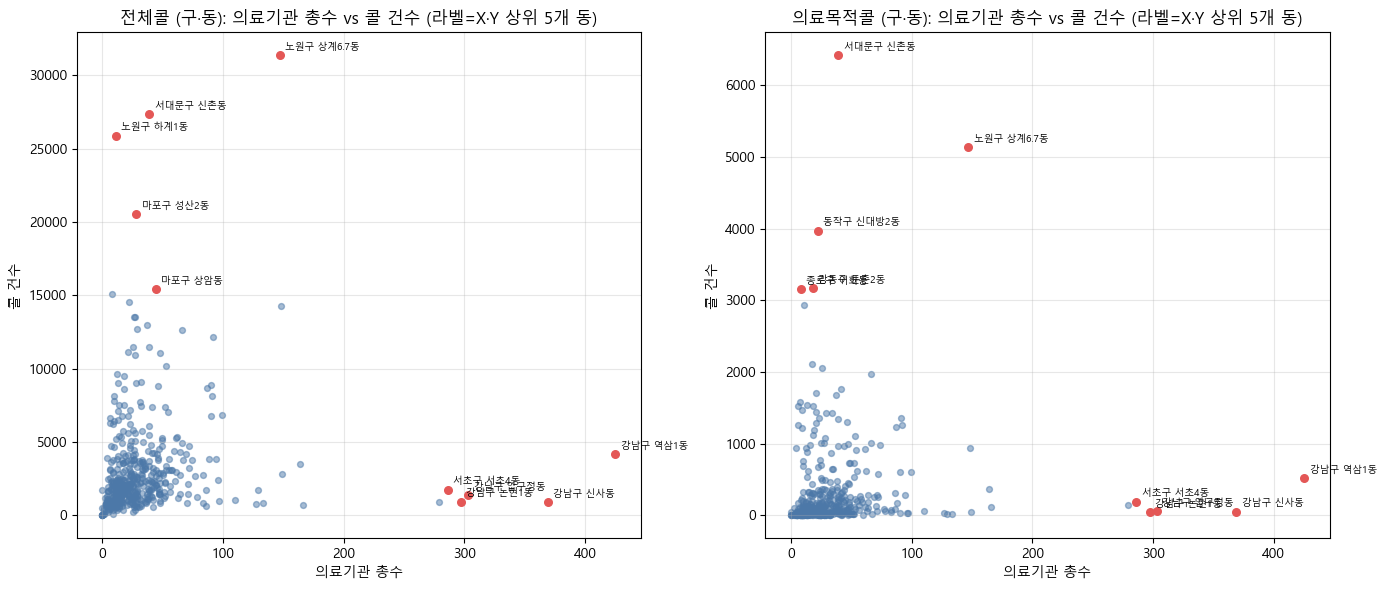

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

N_LABEL = 5  # X(의료기관 수) 상위 N개 + Y(콜 건수) 상위 N개 동만 라벨 표시

for ax, (name, df) in zip(axes, DATASETS.items()):
    ax.scatter(df["의료기관_총수"], df["콜건수"], s=18, alpha=0.5, color="#4c78a8")

    top_x = df.nlargest(N_LABEL, "의료기관_총수")
    top_y = df.nlargest(N_LABEL, "콜건수")
    outliers = pd.concat([top_x, top_y]).drop_duplicates(subset=["목적구", "행정동"])

    for _, row in outliers.iterrows():
        ax.annotate(
            f"{row['목적구']} {row['행정동']}",
            (row["의료기관_총수"], row["콜건수"]),
            fontsize=7,
            xytext=(4, 4),
            textcoords="offset points",
        )
        ax.scatter(row["의료기관_총수"], row["콜건수"], s=30, color="#e45756", zorder=3)

    ax.set_title(f"{name}: 의료기관 총수 vs 콜 건수 (라벨=X·Y 상위 {N_LABEL}개 동)")
    ax.set_xlabel("의료기관 총수")
    ax.set_ylabel("콜 건수")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. 상관관계 분석 (4-2)

Pearson(선형)과 Spearman(순위, 이상치에 덜 민감) 두 방법을 함께 제시한다. 데이터가 오른쪽으로 크게 치우쳐 있어(강남구 역삼1동 등
소수 동에 의료기관이 몰려 있음) Spearman이 더 안정적인 지표일 가능성이 높지만, 두 값을 모두 보고 판단한다.

**[검증 필요]** 아래 상관계수는 인구·면적으로 정규화하지 않은 원 건수 기준이다 — 동 규모 자체가 만든 공통 원인(confounding)일 가능성을 배제할 수 없다.

In [4]:
def corr_report(df, label):
    x = df["의료기관_총수"]
    y = df["콜건수"]
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    return {
        "데이터셋": label,
        "n": len(df),
        "Pearson r": round(pearson_r, 3),
        "Pearson p": f"{pearson_p:.2e}",
        "Spearman rho": round(spearman_r, 3),
        "Spearman p": f"{spearman_p:.2e}",
    }


corr_summary = pd.DataFrame([corr_report(df, name) for name, df in DATASETS.items()])
display(corr_summary)

,데이터셋,n,Pearson r,Pearson p,Spearman rho,Spearman p
0,전체콜 (구·동),431,0.093,5.40e-02,0.286,1.54e-09
1,의료목적콜 (구·동),416,0.062,2.04e-01,0.316,4.44e-11


해석: Spearman 값(0.286, 0.316)은 "약함"에 걸쳐있는 수준임. 즉 "의료기관 많은 동네일수록 콜택시도 많이 간다"는 경향이 분명히 존재하긴 하지만, 그렇게 강한 관계는 아니다.

In [5]:
# 이상치 영향 확인: 의료기관 총수 상위 1%를 제외했을 때 상관계수가 얼마나 바뀌는지
for name, df in DATASETS.items():
    cutoff = df["의료기관_총수"].quantile(0.99)
    trimmed = df[df["의료기관_총수"] <= cutoff]
    r_full, _ = stats.spearmanr(df["의료기관_총수"], df["콜건수"])
    r_trim, _ = stats.spearmanr(trimmed["의료기관_총수"], trimmed["콜건수"])
    print(f"{name}: 상위 1%(cutoff={cutoff:.0f}) 제외 전 Spearman={r_full:.3f} / 제외 후={r_trim:.3f} "
          f"(제외된 동 수: {len(df) - len(trimmed)})")

전체콜 (구·동): 상위 1%(cutoff=284) 제외 전 Spearman=0.286 / 제외 후=0.302 (제외된 동 수: 5)
의료목적콜 (구·동): 상위 1%(cutoff=285) 제외 전 Spearman=0.316 / 제외 후=0.318 (제외된 동 수: 5)


## 3. 의료기관 종별별 관계 분석 (4-3)

종별을 하나로 합친 총수가 아니라, 종별 각각과 콜 건수의 관계를 따로 확인한다.

데이터셋,의료목적콜 (구·동),전체콜 (구·동)
종별,,
의원,0.287,0.261
한의원,0.280,0.282
병원,0.263,0.159
종합병원,0.410,0.309
요양병원,0.243,0.221
상급종합병원,0.283,0.203
보건소,0.124,0.124
보건지소,-0.023,0.035
정신병원,0.050,0.109


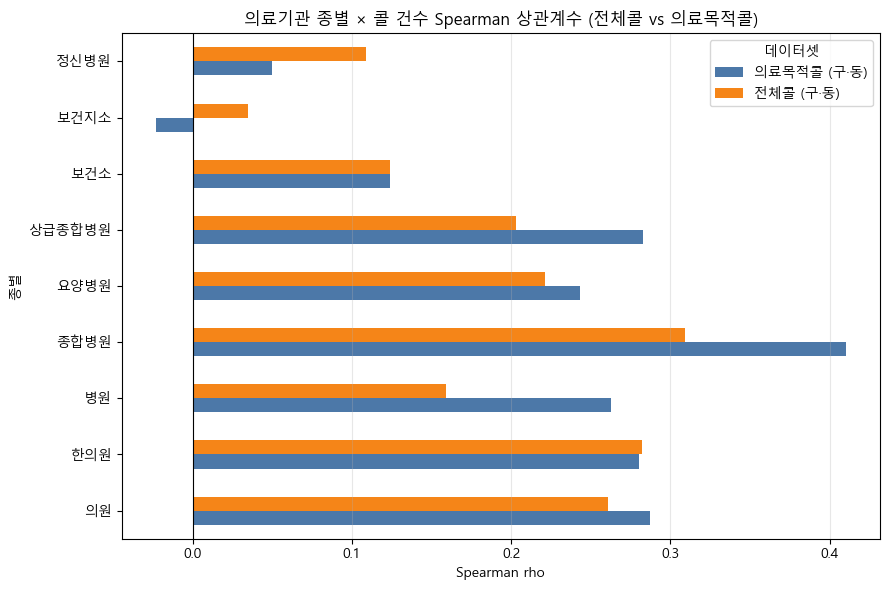

In [6]:
rows = []
for name, df in DATASETS.items():
    for col in FACILITY_COLS:
        rho, p = stats.spearmanr(df[col], df["콜건수"])
        rows.append({"데이터셋": name, "종별": col, "n": len(df), "Spearman rho": round(rho, 3), "p": f"{p:.2e}"})

by_type_corr = pd.DataFrame(rows)
pivot_rho = by_type_corr.pivot(index="종별", columns="데이터셋", values="Spearman rho").loc[FACILITY_COLS]
display(pivot_rho)

pivot_rho.plot(kind="barh", figsize=(9, 6), color=["#4c78a8", "#f58518"])
plt.title("의료기관 종별 × 콜 건수 Spearman 상관계수 (전체콜 vs 의료목적콜)")
plt.xlabel("Spearman rho")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**결과적으로 알게 된 것: 9개 병원 종류 중 종합병원이 제일 관계가 강했다.**

## 4. 지역 유형화 (4-4)

구·동을 의료기관 총수·콜 건수 중앙값 기준으로 4분면으로 나눈다 (전체콜 기준).

- A형: 의료기관 多 + 콜 多
- B형: 의료기관 多 + 콜 少
- C형: 의료기관 少 + 콜 多
- D형: 의료기관 少 + 콜 少

유형
A (의료多+콜多)    136
D (의료少+콜少)    128
B (의료多+콜少)     87
C (의료少+콜多)     80
Name: count, dtype: int64


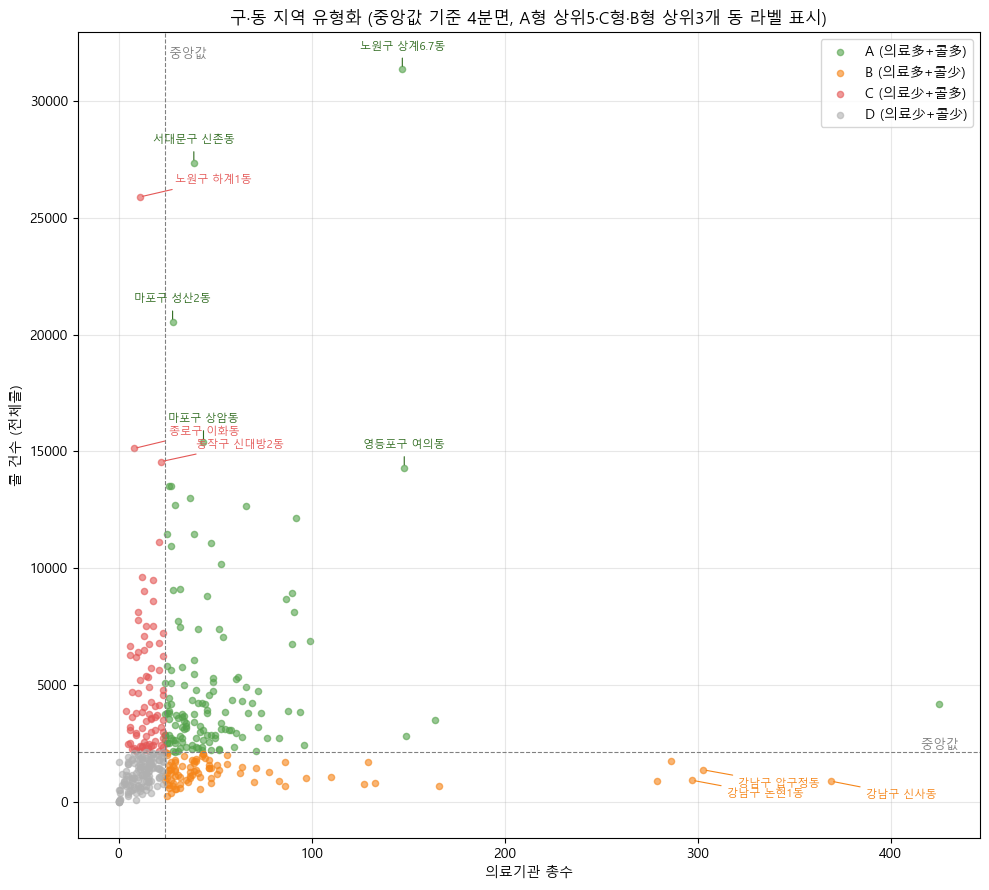

In [7]:
df_q = dong_all.copy()
med_x = df_q["의료기관_총수"].median()
med_y = df_q["콜건수"].median()

def classify(row):
    if row["의료기관_총수"] >= med_x and row["콜건수"] >= med_y:
        return "A (의료多+콜多)"
    if row["의료기관_총수"] >= med_x and row["콜건수"] < med_y:
        return "B (의료多+콜少)"
    if row["의료기관_총수"] < med_x and row["콜건수"] >= med_y:
        return "C (의료少+콜多)"
    return "D (의료少+콜少)"

df_q["유형"] = df_q.apply(classify, axis=1)

print(df_q["유형"].value_counts())

colors = {"A (의료多+콜多)": "#54a24b", "B (의료多+콜少)": "#f58518", "C (의료少+콜多)": "#e45756", "D (의료少+콜少)": "#b0b0b0"}
fig, ax = plt.subplots(figsize=(10, 9))
for label, sub in df_q.groupby("유형"):
    ax.scatter(sub["의료기관_총수"], sub["콜건수"], s=20, alpha=0.6, label=label, color=colors[label])

ax.axvline(med_x, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=0.8)
ax.text(med_x, ax.get_ylim()[1] * 0.98, " 중앙값", color="gray", fontsize=9, va="top", ha="left")
ax.text(ax.get_xlim()[1] * 0.98, med_y, "중앙값 ", color="gray", fontsize=9, va="bottom", ha="right")

# C형(의료少+콜多) 상위 3개, B형(의료多+콜少) 상위 3개 동에 이름표를 달아준다.
# 점이 몰려있어 바로 옆에 쓰면 겹치므로, 화살표 선으로 살짝 떨어뜨려 표시한다.
top_a = df_q[df_q["유형"] == "A (의료多+콜多)"].nlargest(5, "콜건수")
top_c = df_q[df_q["유형"] == "C (의료少+콜多)"].nlargest(3, "콜건수")
top_b = df_q[df_q["유형"] == "B (의료多+콜少)"].nlargest(3, "의료기관_총수")

for _, row in top_a.iterrows():
    ax.annotate(
        f"{row['목적구']} {row['행정동']}",
        xy=(row["의료기관_총수"], row["콜건수"]),
        xytext=(0, 14),
        textcoords="offset points",
        fontsize=8,
        color="#2f6b1f",
        ha="center",
        arrowprops=dict(arrowstyle="-", color="#2f6b1f", linewidth=0.8),
    )

for _, row in top_c.iterrows():
    ax.annotate(
        f"{row['목적구']} {row['행정동']}",
        xy=(row["의료기관_총수"], row["콜건수"]),
        xytext=(25, 10),
        textcoords="offset points",
        fontsize=8,
        color="#e45756",
        arrowprops=dict(arrowstyle="-", color="#e45756", linewidth=0.8),
    )

for _, row in top_b.iterrows():
    ax.annotate(
        f"{row['목적구']} {row['행정동']}",
        xy=(row["의료기관_총수"], row["콜건수"]),
        xytext=(25, -12),
        textcoords="offset points",
        fontsize=8,
        color="#f58518",
        ha="left",
        arrowprops=dict(arrowstyle="-", color="#f58518", linewidth=0.8),
    )

ax.set_xlabel("의료기관 총수")
ax.set_ylabel("콜 건수 (전체콜)")
ax.set_title("구·동 지역 유형화 (중앙값 기준 4분면, A형 상위5·C형·B형 상위3개 동 라벨 표시)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print("[관찰] A형(의료多+콜多) 상위 10개 — 의료 인프라도 많고 목적지 수요도 큰 지역")
display(
    df_q[df_q["유형"] == "A (의료多+콜多)"]
    .sort_values("콜건수", ascending=False)
    .head(10)[["목적구", "행정동", "콜건수", "의료기관_총수"]]
)

print("\n[관찰] C형(의료少+콜多) 상위 10개 — 의료 인프라 대비 목적지 수요가 큰 지역")
display(
    df_q[df_q["유형"] == "C (의료少+콜多)"]
    .sort_values("콜건수", ascending=False)
    .head(10)[["목적구", "행정동", "콜건수", "의료기관_총수"]]
)

print("\n[관찰] B형(의료多+콜少) 상위 10개 — 의료 인프라는 많은데 목적지 수요는 적은 지역")
display(
    df_q[df_q["유형"] == "B (의료多+콜少)"]
    .sort_values("의료기관_총수", ascending=False)
    .head(10)[["목적구", "행정동", "콜건수", "의료기관_총수"]]
)

[관찰] A형(의료多+콜多) 상위 10개 — 의료 인프라도 많고 목적지 수요도 큰 지역


,목적구,행정동,콜건수,의료기관_총수
141,노원구,상계6.7동,31372,147
218,서대문구,신촌동,27363,39
206,마포구,성산2동,20545,28
202,마포구,상암동,15420,44
341,영등포구,여의동,14308,148
427,중랑구,신내1동,13529,26
22,강동구,강일동,13505,27
370,은평구,역촌동,13003,37
219,서대문구,연희동,12702,29
61,강서구,방화1동,12674,66



[관찰] C형(의료少+콜多) 상위 10개 — 의료 인프라 대비 목적지 수요가 큰 지역


,목적구,행정동,콜건수,의료기관_총수
151,노원구,하계1동,25892,11
384,종로구,이화동,15126,8
195,동작구,신대방2동,14564,22
362,은평구,구산동,11126,21
154,도봉구,도봉2동,9638,12
79,관악구,보라매동,9495,18
30,강동구,상일1동,9019,13
27,강동구,둔촌2동,8612,18
145,노원구,월계2동,8145,10
223,서대문구,홍은2동,7788,10



[관찰] B형(의료多+콜少) 상위 10개 — 의료 인프라는 많은데 목적지 수요는 적은 지역


,목적구,행정동,콜건수,의료기관_총수
15,강남구,신사동,885,369
16,강남구,압구정동,1368,303
4,강남구,논현1동,924,297
241,서초구,서초4동,1748,286
21,강남구,청담동,896,279
5,강남구,논현2동,691,166
244,서초구,잠원동,825,133
239,서초구,서초2동,1702,129
228,서초구,반포1동,780,127
304,송파구,잠실본동,1048,110


## 5. 의료기관 '총량'과 '구성' 분리 분석 (4-5)

의료기관 총수가 비슷한 구·동이라도 종별 구성(의원 중심 vs 병원급 중심)이 다를 수 있다. 총수 상위 20개 구·동의 P1 내 구성비를 비교한다.

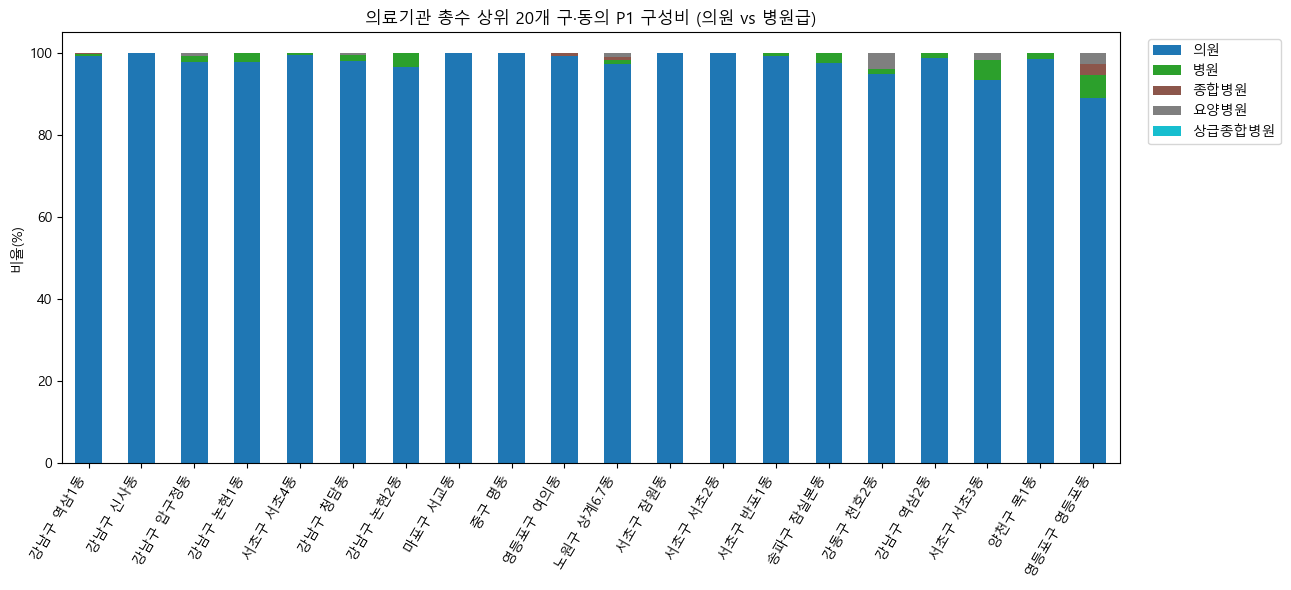

[관찰] 총수는 비슷해도 의원 비중이 90% 넘는 곳과, 병원급 비중이 상대적으로 높은 곳이 함께 섞여 있다.


In [9]:
top_facility = dong_all.sort_values("의료기관_총수", ascending=False).head(20).copy()
p1_cols = ["의원", "병원", "종합병원", "요양병원", "상급종합병원"]
comp = top_facility.set_index(top_facility["목적구"] + " " + top_facility["행정동"])[p1_cols]
comp_ratio = comp.div(comp.sum(axis=1), axis=0) * 100

comp_ratio.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="tab10")
plt.title("의료기관 총수 상위 20개 구·동의 P1 구성비 (의원 vs 병원급)")
plt.ylabel("비율(%)")
plt.xticks(rotation=60, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("[관찰] 총수는 비슷해도 의원 비중이 90% 넘는 곳과, 병원급 비중이 상대적으로 높은 곳이 함께 섞여 있다.")

## 6. 주요 지역 심층 분석 (4-6)

06 EDA에서 식별한 구 단위 '순위차이' 후보 지역을 구·동 데이터로 다시 확인한다.
**특정 지역의 결과를 전체 서울시로 일반화하지 않는다.**

In [10]:
candidate_gu = ["서대문구", "도봉구", "중랑구", "노원구", "은평구", "서초구", "강남구", "중구", "광진구", "송파구"]

candidate_detail = (
    dong_all[dong_all["목적구"].isin(candidate_gu)]
    .groupby("목적구")
    .agg(콜건수_합계=("콜건수", "sum"), 의료기관_총수_합계=("의료기관_총수", "sum"), 동_개수=("행정동", "count"))
    .reindex(candidate_gu)
)
candidate_detail["동당_평균_콜건수"] = (candidate_detail["콜건수_합계"] / candidate_detail["동_개수"]).round(0)
candidate_detail["동당_평균_의료기관수"] = (candidate_detail["의료기관_총수_합계"] / candidate_detail["동_개수"]).round(1)

display(candidate_detail)

,콜건수_합계,의료기관_총수_합계,동_개수,동당_평균_콜건수,동당_평균_의료기관수
목적구,,,,,
서대문구,77346,328,14,5525.0,23.4
도봉구,47460,274,14,3390.0,19.6
중랑구,56697,420,16,3544.0,26.2
노원구,146831,561,19,7728.0,29.5
은평구,74925,528,16,4683.0,33.0
서초구,36283,1279,18,2016.0,71.1
강남구,49717,2618,22,2260.0,119.0
중구,24064,429,22,1094.0,19.5
광진구,41518,444,15,2768.0,29.6


## 인사이트 정리

**[확인된 사실]**
- 구·동 단위 의료기관 총수와 콜 건수의 **Pearson 상관계수는 약함** (전체콜: r=0.093, p=0.054 / 의료목적콜: r=0.062, p=0.204 — 둘 다 통상적 유의수준 0.05를 통과하지 못하거나 경계선).
- 반면 **Spearman 순위상관은 뚜렷하고 통계적으로 유의**하다 (전체콜: rho=0.286, p=1.5e-09 / 의료목적콜: rho=0.316, p=4.4e-11, n=416~431). 데이터가 소수 지역에 심하게 치우쳐 있어(강남구 역삼1동 등) 선형(Pearson)보다 순위(Spearman) 지표가 이 관계를 더 잘 포착한다.
- 의료기관 총수 상위 1%(강남·서초권 중심)를 제외해도 Spearman이 거의 변하지 않는다(전체콜 0.286→0.302, 의료목적콜 0.316→0.318) — 소수 극단치가 만든 착시가 아니라 전반적으로 관찰되는 경향이다.
- 지역 유형화 결과: A(의료多+콜多) 136개, D(의료少+콜少) 128개, B(의료多+콜少) 87개, C(의료少+콜多) 80개 동 — 네 유형 모두 상당수 존재해 '의료기관이 많으면 콜도 많다'는 단순 도식만으로는 설명되지 않는다.

**[탐색적 관계]**
- 종별로는 **종합병원**이 콜 건수와 가장 강하게 연관된다 (전체콜 rho=0.309, **의료목적콜 rho=0.410로 더 강해짐**). 의원(0.261/0.287), 한의원(0.282/0.280), 상급종합병원(0.203/0.283)도 뒤를 잇는다. 반면 보건지소(0.035/-0.023)·정신병원(0.109/0.050)은 거의 무관하다 — 표본이 작은 종별이라 노이즈일 가능성이 크다.
- **전체콜보다 의료목적콜에서 종합병원·상급종합병원의 상관이 뚜렷하게 강해진다** — 이용목적을 의료로 좁힐수록 '의료기관이 많은 곳으로 실제 의료 목적 이동이 몰린다'는 관계가 더 선명해지는 방향이라, 9-2절에서 도입한 의료목적콜 필터링이 실제로 신호를 더 잘 잡아낸다는 정황이다.
- **B형(의료多+콜少)** 상위 지역이 강남구(신사동·압구정동·논현1·2동·청담동)·서초구(서초4동·잠원동·서초2동·반포1동)에 몰려 있다 — 의료기관은 매우 많지만(예: 강남구 동당 평균 119.0개) 콜 목적지 건수는 오히려 적은(동당 평균 2,260건) 지역.
- **C형(의료少+콜多)** 상위 지역은 노원구 하계1동·월계2동, 종로구 이화동, 동작구 신대방2동, 은평구 구산동, 도봉구 도봉2동, 관악구 보라매동, 강동구 상일1동·둔촌2동, 서대문구 홍은2동 등으로 흩어져 있다 — 특정 한 구에 쏠리지 않고 여러 구에 분산.
- 노원구는 동당 평균 콜 건수 7,728건으로 서울에서 압도적으로 높은데(2위 은평구 4,683건), 동당 평균 의료기관 수는 29.5개로 중간 수준이다 — 콜 목적지 수요는 매우 크지만 의료 인프라는 그에 비례해 크지 않은 지역 후보.

**[가설]**
- C형 지역(노원구·도봉구·동작구·은평구 일부 등)은 의료 인프라 대비 콜 목적지 수요가 큰 지역일 수 있다는 가설을 세울 수 있다.
- 종합병원·상급종합병원처럼 병원급 이상 의료기관이 콜 목적지 패턴과 더 밀접하게 연관될 수 있다는 가설도 세울 수 있다 (의료목적콜에서 상관이 강해지는 패턴과 일치).
- 두 가설 모두 대기시간·차량 배치·인구 구조 등 다른 지표와 함께 검증이 필요하며, 이 노트북만으로 확정할 수 없다.

**[인과관계 — 주장하지 않음]**
- "의료기관이 많아서 콜 이용량이 늘었다" 또는 "장애인콜택시 이용자가 특정 병원을 많이 방문한다"는 주장은 하지 않는다.
- 인구·면적을 보정하지 않았으므로, 관찰된 상관관계가 동 규모라는 공통 원인에서 비롯됐을 가능성을 배제할 수 없다.

## 한계 및 추가 분석 방향

- **인구·면적 미보정**: 이번 분석에서 가장 큰 한계. 향후 `서울시장애인현황(등급별_동별)` 데이터로 인구 대비 정규화를 추가하면 상관관계의 신뢰도를 높일 수 있다 (07 작업 전 재검토에서 의도적으로 이번 범위에서 제외하기로 결정함).
- **Pearson vs Spearman 괴리**: 선형 상관은 약하고 순위 상관은 뚜렷한 이번 결과 자체가, 데이터 분포가 심하게 치우쳐 있다는 신호다. 추후 로그 변환 등으로 분포를 조정한 뒤 재확인할 필요가 있다.
- **동 단위 매칭 잔여 0.17%**: 서빙고동(실제 0건 확인)과 중구 일부(인천 동명 혼입 의심)는 미해결로 남아있다 (05 노트북 2-6절 참고).
- **진료과목 분석 불가**: 재활의학과 등 세부 진료과목은 현재 HIRA 데이터로 확인할 수 없다.
- **다음 분석 제안**: (1) 인구 대비 정규화, (2) 대기시간·배차시간과 의료기관 분포의 관계, (3) 서울 외 지역(경기권) 목적지와의 비교, (4) `03_same_gu_movement_analysis.ipynb`(미실행) 결과와의 교차 검토, (5) 종합병원·상급종합병원만 따로 뗀 상관분석으로 이번에 발견한 '병원급이 더 강한 관계' 가설 정밀 검증.